# Multi-Model Comparison: Interval Detection

## Overview

This notebook provides a systematic comparison across ten interval detection models:

| Model | Type | Features |
|-------|------|----------|
| **XGBoost** | Gradient Boosting (tree-based) | Full feature set |
| **FFNN** | Feed-Forward Neural Network | Full feature set |
| **BiLSTM** | Bidirectional LSTM | Full feature set |
| **BiLSTM (reduced)** | Bidirectional LSTM | Reduced feature set |
| **TCN** | Temporal Convolutional Network (dilated) | Full feature set |
| **TCN (reduced)** | Temporal Convolutional Network (dilated) | Reduced feature set |
| **CNN** | Convolutional Neural Network (improved) | Full feature set |
| **CNN (reduced)** | Convolutional Neural Network (improved) | Reduced feature set |
| **U-Net** | 1D U-Net (encoder-decoder with skip connections) | Full feature set |
| **U-Net (reduced)** | 1D U-Net (encoder-decoder with skip connections) | Reduced feature set |

All models were evaluated on the same set of athletic training sessions using a **leave-one-session-out** cross-validation strategy. Each session is held out as a test set while the remaining sessions are used for training.

### Evaluation Metrics

| Metric | Description |
|--------|-------------|
| **F_beta** | Weighted harmonic mean of precision and recall (primary metric) |
| **Precision** | Fraction of predicted intervals that are correct (fewer false positives = higher precision) |
| **Recall** | Fraction of true intervals that were detected (fewer missed intervals = higher recall) |
| **MAE (seconds)** | Mean absolute timing error between predicted and true interval boundaries |

In [1]:
# ============================================================================
# MULTI-MODEL COMPARISON ANALYSIS
# ============================================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print("=" * 70)
print("MULTI-MODEL COMPARISON ANALYSIS")
print("=" * 70)

# ============================================================================
# 1. DEFINE AND LOAD ALL MODELS
# ============================================================================

MODELS = OrderedDict([
    ('XGBoost',          'results/xgboost_results.pkl'),
    ('FFNN',             'results/FFNN_results.pkl'),
    ('BiLSTM',           'results/bilstm_results.pkl'),
    ('BiLSTM (reduced)', 'results/bilstm_reduced_results.pkl'),
    ('TCN',              'results/tcn_dilated_results.pkl'),
    ('TCN (reduced)',    'results/tcn_dilated_reduced_results.pkl'),
    ('CNN',              'results/cnn_improved_results.pkl'),
    ('CNN (reduced)',    'results/cnn_improved_reduced_results.pkl'),
    ('U-Net',            'results/unet_1d_results.pkl'),
    ('U-Net (reduced)',  'results/unet_1d_reduced_results.pkl'),
])

MODEL_STYLES = {
    'XGBoost':          {'color': '#1f77b4', 'marker': 's'},
    'FFNN':             {'color': '#ff7f0e', 'marker': 'o'},
    'BiLSTM':           {'color': '#2ca02c', 'marker': '^'},
    'BiLSTM (reduced)': {'color': '#98df8a', 'marker': 'v'},
    'TCN':              {'color': '#d62728', 'marker': 'D'},
    'TCN (reduced)':    {'color': '#ff9896', 'marker': 'd'},
    'CNN':              {'color': '#9467bd', 'marker': 'P'},
    'CNN (reduced)':    {'color': '#c5b0d5', 'marker': 'X'},
    'U-Net':            {'color': '#8c564b', 'marker': 'h'},
    'U-Net (reduced)':  {'color': '#c49c94', 'marker': 'H'},
}

# Load all results
all_results = {}  # {model_name: {session_id: result_dict}}
print("\nLoading models:")
for name, path in MODELS.items():
    with open(path, 'rb') as f:
        package = pickle.load(f)
    results_list = package['results']
    all_results[name] = {res['session']: res for res in results_list}
    print(f"  {name}: {len(results_list)} sessions")

# Find common sessions across ALL models
all_session_sets = [set(d.keys()) for d in all_results.values()]
common_sessions = set.intersection(*all_session_sets)
print(f"\nCommon sessions across all {len(MODELS)} models: {len(common_sessions)}")

for name in MODELS:
    extra = set(all_results[name].keys()) - common_sessions
    if extra:
        print(f"  {name} extra sessions (excluded): {len(extra)}")

# ============================================================================
# 2. BUILD LONG-FORMAT COMPARISON DATAFRAME
# ============================================================================

rows = []
for session_id in sorted(common_sessions):
    ref_res = all_results['XGBoost'][session_id]
    df_session = ref_res['df']

    sport = ref_res.get('sport', 'unknown')
    if sport == 'unknown':
        if 'Bike' in ref_res['athlete'] or 'Zwift' in session_id:
            sport = 'biking'
        else:
            sport = 'rowing'

    for model_name in MODELS:
        res = all_results[model_name][session_id]
        rows.append({
            'session': session_id,
            'athlete': ref_res['athlete'],
            'sport': sport,
            'n_intervals': ref_res['n_true'],
            'duration_sec': len(df_session),
            'model': model_name,
            'f_beta': res['f_beta'],
            'precision': res['precision'],
            'recall': res['recall'],
            'mae': res.get('mean_error_sec', np.nan),
            'n_pred': res['n_pred'],
            'n_true': res['n_true'],
        })

df_long = pd.DataFrame(rows)
df_long['complexity'] = pd.cut(
    df_long['n_intervals'],
    bins=[0, 10, 20, 100],
    labels=['Low (<=10)', 'Medium (11-20)', 'High (>20)']
)

print(f"\nDataframe: {len(df_long)} rows "
      f"({len(common_sessions)} sessions x {len(MODELS)} models)")

# ============================================================================
# 3. OVERALL PERFORMANCE RANKING
# ============================================================================

print("\n" + "=" * 70)
print("OVERALL PERFORMANCE RANKING (sorted by mean F_beta)")
print("=" * 70)

overall_stats = df_long.groupby('model').agg(
    F_beta_mean=('f_beta', 'mean'),
    F_beta_std=('f_beta', 'std'),
    Precision_mean=('precision', 'mean'),
    Recall_mean=('recall', 'mean'),
    MAE_mean=('mae', 'mean'),
).round(3).sort_values('F_beta_mean', ascending=False)

overall_stats.index.name = 'Model'
model_order = overall_stats.index.tolist()
print()
display(overall_stats)

# ============================================================================
# 4. BEST MODEL PER SESSION
# ============================================================================

print("\n" + "=" * 70)
print("BEST MODEL PER SESSION (by F_beta)")
print("=" * 70)

best_per_session = df_long.loc[df_long.groupby('session')['f_beta'].idxmax()]
win_counts = best_per_session['model'].value_counts()

print("\nSessions where each model achieved highest F_beta:")
for model, count in win_counts.items():
    pct = 100 * count / len(common_sessions)
    print(f"  {model}: {count} ({pct:.1f}%)")

# ============================================================================
# 5. BREAKDOWN BY SPORT
# ============================================================================

print("\n" + "=" * 70)
print("MEAN F_BETA BY SPORT")
print("=" * 70)

sport_table = df_long.pivot_table(
    values='f_beta', index='model', columns='sport', aggfunc='mean'
).round(3).loc[model_order]
print()
display(sport_table)

# ============================================================================
# 6. BREAKDOWN BY COMPLEXITY
# ============================================================================

print("\n" + "=" * 70)
print("MEAN F_BETA BY COMPLEXITY")
print("=" * 70)

comp_table = df_long.pivot_table(
    values='f_beta', index='model', columns='complexity',
    aggfunc='mean', observed=False
).round(3).loc[model_order]
print()
display(comp_table)

# ============================================================================
# 7. SESSION-BY-SESSION: BEST AND WORST MODELS
# ============================================================================

print("\n" + "=" * 70)
print("SESSION-BY-SESSION: BEST AND WORST MODELS")
print("=" * 70)

fbeta_wide = df_long.pivot_table(values='f_beta', index='session', columns='model')

print(f"\n{'Session':<48} {'Best Model':<20} {'Score':>6}  {'Worst Model':<20} {'Score':>6}")
print("-" * 110)
for session_id in sorted(common_sessions):
    row = fbeta_wide.loc[session_id]
    best_m = row.idxmax()
    worst_m = row.idxmin()
    s = session_id[:45] + "..." if len(session_id) > 48 else session_id
    print(f"  {s:<48} {best_m:<20} {row.max():>6.3f}  {worst_m:<20} {row.min():>6.3f}")

print("\n" + "=" * 70)
print("DATA LOADING COMPLETE")
print("=" * 70)

MULTI-MODEL COMPARISON ANALYSIS

Loading models:
  XGBoost: 18 sessions
  FFNN: 18 sessions
  BiLSTM: 18 sessions
  BiLSTM (reduced): 18 sessions
  TCN: 18 sessions
  TCN (reduced): 18 sessions
  CNN: 18 sessions
  CNN (reduced): 18 sessions
  U-Net: 18 sessions
  U-Net (reduced): 18 sessions

Common sessions across all 10 models: 18

Dataframe: 180 rows (18 sessions x 10 models)

OVERALL PERFORMANCE RANKING (sorted by mean F_beta)



,F_beta_mean,F_beta_std,Precision_mean,Recall_mean,MAE_mean
Model,,,,,
BiLSTM,0.722,0.134,0.722,0.722,25.207
FFNN,0.714,0.156,0.715,0.713,18.340
XGBoost,0.700,0.185,0.700,0.700,17.128
TCN,0.678,0.159,0.678,0.678,24.466
CNN,0.678,0.139,0.678,0.678,23.299
U-Net,0.666,0.149,0.666,0.666,32.558
CNN (reduced),0.630,0.140,0.630,0.630,44.868
TCN (reduced),0.584,0.134,0.584,0.584,55.836
BiLSTM (reduced),0.529,0.141,0.529,0.529,42.165



BEST MODEL PER SESSION (by F_beta)

Sessions where each model achieved highest F_beta:
  XGBoost: 7 (38.9%)
  FFNN: 4 (22.2%)
  TCN: 3 (16.7%)
  BiLSTM: 2 (11.1%)
  U-Net: 1 (5.6%)
  CNN: 1 (5.6%)

MEAN F_BETA BY SPORT



sport,biking,rowing
model,,
BiLSTM,0.686,0.739
FFNN,0.661,0.740
XGBoost,0.558,0.771
TCN,0.598,0.718
CNN,0.558,0.739
U-Net,0.590,0.704
CNN (reduced),0.569,0.661
TCN (reduced),0.566,0.593
BiLSTM (reduced),0.458,0.564



MEAN F_BETA BY COMPLEXITY



complexity,Low (<=10),Medium (11-20),High (>20)
model,,,
BiLSTM,0.738,0.716,0.699
FFNN,0.705,0.759,0.663
XGBoost,0.759,0.715,0.559
TCN,0.686,0.739,0.570
CNN,0.708,0.697,0.591
U-Net,0.706,0.736,0.481
CNN (reduced),0.619,0.622,0.666
TCN (reduced),0.575,0.626,0.540
BiLSTM (reduced),0.542,0.554,0.465



SESSION-BY-SESSION: BEST AND WORST MODELS

Session                                          Best Model            Score  Worst Model           Score
--------------------------------------------------------------------------------------------------------------
  10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Wat... BiLSTM                0.750  BiLSTM (reduced)      0.500
  11783093951_4x2000_sub8                          BiLSTM                0.778  CNN (reduced)         0.444
  11846980624_Platt_                               XGBoost               0.900  FFNN                  0.600
  11962243206_Wundmanagement                       FFNN                  1.000  U-Net (reduced)       0.500
  12036692734_Exhausted                            XGBoost               0.778  TCN                   0.444
  12069656901_Schwitzen_im_Sitzen                  BiLSTM                0.714  BiLSTM (reduced)      0.286
  12846436186_Synchronflug                         BiLSTM                1.000  BiLSTM (red

## Interpretation: Overall Comparison

### Overall Ranking

**BiLSTM** leads the field with a mean F_beta of 0.722, followed closely by **FFNN** (0.714) and **XGBoost** (0.700). **TCN** and **CNN** are tied at 0.678, with **U-Net** (0.666) rounding out a competitive top-6 tier. The remaining four models -- all reduced-feature variants -- fall noticeably behind, with F_beta values ranging from 0.521 to 0.630.

### Best Model Per Session

**XGBoost** wins the most individual sessions: 7 out of 18 (38.9%). **FFNN** wins 4 sessions (22.2%), **TCN** wins 3 (16.7%), and **BiLSTM** wins 2 (11.1%). **U-Net** and **CNN** each win 1 session. Notably, none of the reduced-feature models are ever the top performer on any session.

### By Sport

All models perform better on **rowing** than on **biking**. The gap is particularly large for XGBoost (0.771 rowing vs 0.558 biking, a difference of 0.213). BiLSTM leads biking (0.686), while XGBoost leads rowing (0.771). FFNN shows the smallest sport gap among top models (0.740 vs 0.661, difference of 0.079), making it the most sport-agnostic choice.

### By Complexity

Most models achieve their best scores on **low-complexity** sessions (<=10 intervals), with XGBoost leading at 0.759 and BiLSTM close behind at 0.738. Performance generally drops on high-complexity sessions (>20 intervals), where BiLSTM maintains the best score (0.699). XGBoost drops most steeply to 0.559 at high complexity. FFNN leads on medium-complexity sessions (0.759).

### Full vs Reduced Features

Across all four architectures tested in both variants (BiLSTM, TCN, CNN, U-Net), the **full feature set always outperforms the reduced set**. The largest gap is BiLSTM (0.722 vs 0.529, -0.193), and the smallest is CNN (0.678 vs 0.630, -0.048). This indicates that the additional features provide meaningful signal that all architectures can leverage.

### Session-by-Session Best/Worst

Some sessions are consistently easy: e.g., session "Wundmanagement" where the best model (FFNN) achieves a perfect 1.000, and "Synchronflug" where BiLSTM also reaches 1.000. Other sessions reveal stark model differences: on "Zwift Aerobic Mixup", U-Net scores 0.684 while U-Net (reduced) scores only 0.105 -- a gap of 0.579. On "Schwitzen_im_Sitzen", BiLSTM scores 0.714 while BiLSTM (reduced) scores only 0.286.

## Detailed Summary Tables

In [2]:
# ============================================================================
# SUMMARY TABLES
# ============================================================================

metrics = ['f_beta', 'precision', 'recall', 'mae']
metric_labels = ['F_beta', 'Precision', 'Recall', 'MAE (sec)']

# ── Table 1: All metrics for all models ──
print("=" * 60)
print("TABLE 1: Overall Metrics per Model")
print("=" * 60)

table1_rows = []
for model in model_order:
    mdf = df_long[df_long['model'] == model]
    table1_rows.append({
        'Model': model,
        'F_beta': mdf['f_beta'].mean(),
        'Precision': mdf['precision'].mean(),
        'Recall': mdf['recall'].mean(),
        'MAE (sec)': mdf['mae'].mean(),
    })
table1 = pd.DataFrame(table1_rows).set_index('Model').round(3)
display(table1)

# ── Table 2: F_beta per model per sport ──
print("\n" + "=" * 60)
print("TABLE 2: Metrics per Model per Sport")
print("=" * 60)

for metric, label in zip(metrics, metric_labels):
    print(f"\n--- {label} ---")
    pivot = df_long.pivot_table(
        values=metric, index='model', columns='sport', aggfunc='mean'
    ).round(3).loc[model_order]
    display(pivot)

# ── Table 3: F_beta per model per complexity ──
print("\n" + "=" * 60)
print("TABLE 3: Metrics per Model per Complexity")
print("=" * 60)

for metric, label in zip(metrics, metric_labels):
    print(f"\n--- {label} ---")
    pivot = df_long.pivot_table(
        values=metric, index='model', columns='complexity',
        aggfunc='mean', observed=False
    ).round(3).loc[model_order]
    display(pivot)

# ── Table 4: Win counts by sport and complexity ──
print("\n" + "=" * 60)
print("TABLE 4: Win Counts (sessions where model is best)")
print("=" * 60)

best = df_long.loc[df_long.groupby('session')['f_beta'].idxmax()]

print("\nBy Sport:")
win_sport = best.pivot_table(
    index='model', columns='sport', values='session',
    aggfunc='count', fill_value=0
)
win_sport['Total'] = win_sport.sum(axis=1)
win_sport = win_sport.sort_values('Total', ascending=False)
display(win_sport)

print("\nBy Complexity:")
win_comp = best.pivot_table(
    index='model', columns='complexity', values='session',
    aggfunc='count', fill_value=0, observed=False
)
win_comp['Total'] = win_comp.sum(axis=1)
win_comp = win_comp.sort_values('Total', ascending=False)
display(win_comp)

TABLE 1: Overall Metrics per Model


,F_beta,Precision,Recall,MAE (sec)
Model,,,,
BiLSTM,0.722,0.722,0.722,25.207
FFNN,0.714,0.715,0.713,18.340
XGBoost,0.700,0.700,0.700,17.128
TCN,0.678,0.678,0.678,24.466
CNN,0.678,0.678,0.678,23.299
U-Net,0.666,0.666,0.666,32.558
CNN (reduced),0.630,0.630,0.630,44.868
TCN (reduced),0.584,0.584,0.584,55.836
BiLSTM (reduced),0.529,0.529,0.529,42.165



TABLE 2: Metrics per Model per Sport

--- F_beta ---


sport,biking,rowing
model,,
BiLSTM,0.686,0.739
FFNN,0.661,0.740
XGBoost,0.558,0.771
TCN,0.598,0.718
CNN,0.558,0.739
U-Net,0.590,0.704
CNN (reduced),0.569,0.661
TCN (reduced),0.566,0.593
BiLSTM (reduced),0.458,0.564



--- Precision ---


...

complexity,Low (<=10),Medium (11-20),High (>20)
model,,,
BiLSTM,31.625,22.044,17.116
FFNN,23.687,10.964,18.709
XGBoost,14.549,20.847,16.707
TCN,24.405,18.331,33.790
CNN,26.568,16.145,27.494
U-Net,38.023,22.890,36.134
CNN (reduced),57.595,49.082,13.090
TCN (reduced),86.960,34.198,26.043
BiLSTM (reduced),42.711,42.121,41.136



TABLE 4: Win Counts (sessions where model is best)

By Sport:


sport,biking,rowing,Total
model,,,
XGBoost,0,7,7
FFNN,2,2,4
TCN,1,2,3
BiLSTM,2,0,2
CNN,0,1,1
U-Net,1,0,1



By Complexity:


complexity,Low (<=10),Medium (11-20),High (>20),Total
model,,,,
XGBoost,6,1,0,7
FFNN,1,2,1,4
TCN,1,1,1,3
BiLSTM,0,1,1,2
CNN,0,0,1,1
U-Net,0,1,0,1


## Interpretation: Summary Tables

### Table 1 -- Overall Metrics per Model

BiLSTM leads with an F_beta of 0.722, closely followed by FFNN (0.714) and XGBoost (0.700). Precision and recall are nearly identical for each model (e.g., FFNN: 0.715 / 0.713; XGBoost: 0.700 / 0.700), meaning none of them are systematically biased toward over- or under-predicting intervals. XGBoost achieves the best MAE (17.1 s), followed by FFNN (18.3 s), indicating superior timing accuracy despite ranking third in F_beta. Among the bottom models, U-Net (reduced) has the worst MAE (66.0 s) and TCN (reduced) follows at 55.8 s, indicating poor timing accuracy on top of weak detection performance.

### Table 2 -- Metrics by Sport

**F_beta:** All models perform better on rowing than on biking. XGBoost leads rowing (0.771) while BiLSTM leads biking (0.686). The largest sport gap belongs to U-Net (reduced), which drops from 0.541 on rowing to 0.481 on biking.

**Precision:** XGBoost achieves the highest rowing precision (0.771), while BiLSTM leads biking precision (0.686). The reduced-feature models show notably lower precision on biking (all below 0.57), suggesting they produce more false positives on cycling sessions.

**Recall:** The pattern mirrors precision closely. XGBoost achieves the highest rowing recall (0.771) and BiLSTM the highest biking recall (0.686). BiLSTM (reduced) has the worst biking recall (0.458), missing more than half of all true intervals.

**MAE:** XGBoost has the best timing accuracy on rowing (14.3 s), while FFNN has the best on biking (20.4 s). U-Net (reduced) has the worst rowing MAE (68.8 s), and CNN (reduced) has the worst biking MAE (51.5 s).

### Table 3 -- Metrics by Complexity

**F_beta:** Low-complexity sessions (<=10 intervals) yield the highest scores for XGBoost (0.759) and BiLSTM (0.738). FFNN leads medium-complexity sessions (0.759), nearly tied with TCN (0.739) and U-Net (0.736). At high complexity (>20 intervals), BiLSTM maintains the best score (0.699), followed by CNN (reduced) at 0.666 and FFNN at 0.663. BiLSTM (reduced) drops to 0.465, making it unreliable on complex sessions.

**Precision:** XGBoost maintains the highest precision at low complexity (0.759). FFNN leads medium complexity (0.753). BiLSTM leads high complexity (0.699).

**Recall:** BiLSTM has the best high-complexity recall (0.699), confirming its strength at finding intervals in complex sessions. BiLSTM (reduced) has the worst high-complexity recall (0.465).

**MAE:** FFNN achieves the best timing accuracy on medium-complexity sessions (11.0 s). CNN (reduced) achieves the best MAE on high-complexity sessions (13.1 s). TCN (reduced) has very poor timing on low-complexity sessions (87.0 s), suggesting it over-segments simple sessions.

### Table 4 -- Win Counts

**By sport:** XGBoost's 7 wins are all in rowing, while FFNN's 4 wins are split (2 biking, 2 rowing). TCN wins 3 sessions (1 biking, 2 rowing). BiLSTM wins 2 biking sessions.

**By complexity:** XGBoost dominates low-complexity sessions (6 out of its 7 wins). FFNN wins across all complexity levels (1 low, 2 medium, 1 high). TCN also wins across all levels (1 each). This reflects their complementary strengths: XGBoost excels on simple, well-structured sessions, while FFNN and TCN handle complexity more robustly.

In [3]:
# ============================================================================
# DETAILED METRICS
# ============================================================================

# ── 1. Model Consistency ──
print("=" * 60)
print("1. MODEL CONSISTENCY (F_beta Standard Deviation)")
print("=" * 60)

consistency = df_long.groupby('model')['f_beta'].std().round(3).sort_values()
consistency.name = 'F_beta Std Dev'
display(pd.DataFrame(consistency))
print(f"\nMost consistent:  {consistency.idxmin()} (std = {consistency.min():.3f})")
print(f"Least consistent: {consistency.idxmax()} (std = {consistency.max():.3f})")

# ── 2. Failure Rate ──
print("\n" + "=" * 60)
print("2. FAILURE RATE (sessions with F_beta < 0.5)")
print("=" * 60)

n_sessions = len(common_sessions)
failures = df_long.groupby('model')['f_beta'].apply(
    lambda g: (g < 0.5).sum()
).sort_values()
failure_pct = (failures / n_sessions * 100).round(1)
failure_df = pd.DataFrame({
    'Failures': failures,
    f'Rate (% of {n_sessions})': failure_pct
})
display(failure_df)

# ── 3. False Positive & False Negative Rates ──
print("\n" + "=" * 60)
print("3. FALSE POSITIVE & FALSE NEGATIVE RATES")
print("=" * 60)

fp_fn_rows = []
for model_name in model_order:
    model_df = df_long[df_long['model'] == model_name]
    fp_rates = []
    fn_rates = []
    for _, row in model_df.iterrows():
        tp = row['recall'] * row['n_true']
        fp = row['n_pred'] - tp
        fn = row['n_true'] - tp
        fp_rate = fp / row['n_pred'] if row['n_pred'] > 0 else 0
        fn_rate = fn / row['n_true'] if row['n_true'] > 0 else 0
        fp_rates.append(fp_rate)
        fn_rates.append(fn_rate)
    fp_fn_rows.append({
        'Model': model_name,
        'Avg FP Rate': np.mean(fp_rates),
        'Avg FN Rate': np.mean(fn_rates),
    })

fp_fn_df = pd.DataFrame(fp_fn_rows).set_index('Model').round(3)
display(fp_fn_df)

# ── 4. Full vs Reduced Feature Comparison ──
print("\n" + "=" * 60)
print("4. FULL vs REDUCED FEATURE SET COMPARISON")
print("=" * 60)

pairs = [
    ('BiLSTM', 'BiLSTM (reduced)'),
    ('TCN', 'TCN (reduced)'),
    ('CNN', 'CNN (reduced)'),
    ('U-Net', 'U-Net (reduced)'),
]

pair_rows = []
for full_name, reduced_name in pairs:
    full_scores = df_long[df_long['model'] == full_name].set_index('session')['f_beta']
    red_scores = df_long[df_long['model'] == reduced_name].set_index('session')['f_beta']

    full_mean = full_scores.mean()
    red_mean = red_scores.mean()
    diff = red_mean - full_mean

    full_wins = (full_scores > red_scores).sum()
    red_wins = (red_scores > full_scores).sum()
    ties = (full_scores == red_scores).sum()

    base = full_name.split(' ')[0]
    direction = "better" if diff > 0 else "worse" if diff < 0 else "same"

    pair_rows.append({
        'Architecture': base,
        'Full F_beta': round(full_mean, 3),
        'Reduced F_beta': round(red_mean, 3),
        'Diff (Red-Full)': round(diff, 3),
        'Full Wins': full_wins,
        'Reduced Wins': red_wins,
        'Ties': ties,
    })

    print(f"\n{base}:")
    print(f"  Full features:    {full_mean:.3f}")
    print(f"  Reduced features: {red_mean:.3f}")
    print(f"  Difference:       {diff:+.3f} (reduced is {direction})")
    print(f"  Full wins: {full_wins}, Reduced wins: {red_wins}, Ties: {ties}")

print()
display(pd.DataFrame(pair_rows).set_index('Architecture'))

1. MODEL CONSISTENCY (F_beta Standard Deviation)


,F_beta Std Dev
model,
BiLSTM,0.134
TCN (reduced),0.134
CNN,0.139
CNN (reduced),0.140
BiLSTM (reduced),0.141
U-Net,0.149
U-Net (reduced),0.149
FFNN,0.156
TCN,0.159



Most consistent:  BiLSTM (std = 0.134)
Least consistent: XGBoost (std = 0.185)

2. FAILURE RATE (sessions with F_beta < 0.5)


,Failures,Rate (% of 18)
model,,
BiLSTM,1,5.6
CNN,1,5.6
U-Net,1,5.6
FFNN,1,5.6
TCN,2,11.1
XGBoost,2,11.1
CNN (reduced),3,16.7
BiLSTM (reduced),5,27.8
TCN (reduced),5,27.8



3. FALSE POSITIVE & FALSE NEGATIVE RATES


,Avg FP Rate,Avg FN Rate
Model,,
BiLSTM,0.278,0.278
FFNN,0.287,0.287
XGBoost,0.300,0.300
TCN,0.322,0.322
CNN,0.322,0.322
U-Net,0.334,0.334
CNN (reduced),0.370,0.370
TCN (reduced),0.416,0.416
BiLSTM (reduced),0.471,0.471



4. FULL vs REDUCED FEATURE SET COMPARISON

BiLSTM:
  Full features:    0.722
  Reduced features: 0.529
  Difference:       -0.193 (reduced is worse)
  Full wins: 13, Reduced wins: 0, Ties: 5

TCN:
  Full features:    0.678
  Reduced features: 0.584
  Difference:       -0.094 (reduced is worse)
  Full wins: 9, Reduced wins: 4, Ties: 5

CNN:
  Full features:    0.678
  Reduced features: 0.630
  Difference:       -0.048 (reduced is worse)
  Full wins: 10, Reduced wins: 4, Ties: 4

U-Net:
  Full features:    0.666
  Reduced features: 0.521
  Difference:       -0.145 (reduced is worse)
  Full wins: 11, Reduced wins: 4, Ties: 3



,Full F_beta,Reduced F_beta,Diff (Red-Full),Full Wins,Reduced Wins,Ties
Architecture,,,,,,
BiLSTM,0.722,0.529,-0.193,13,0,5
TCN,0.678,0.584,-0.094,9,4,5
CNN,0.678,0.630,-0.048,10,4,4
U-Net,0.666,0.521,-0.145,11,4,3


## Interpretation: Detailed Metrics

### Model Consistency

**BiLSTM** and **TCN (reduced)** are the most consistent models (std = 0.134 each), meaning their performance is the most predictable across sessions. Among the top-performing models, **CNN** is the most consistent (std = 0.139), while **XGBoost** is the least consistent (std = 0.185), indicating its performance varies most between sessions.

### Failure Rate

**BiLSTM, CNN, U-Net, and FFNN** share the lowest failure rate, each failing on only 1 out of 18 sessions (5.6%). **TCN** and **XGBoost** fail on 2 sessions each (11.1%). The reduced-feature models are considerably less reliable: **BiLSTM (reduced)**, **TCN (reduced)**, and **U-Net (reduced)** each fail on 5 sessions (27.8%), meaning they produce more-wrong-than-right predictions on over a quarter of all sessions.

### False Positive and False Negative Rates

The FP and FN rates are symmetric for all models (equal values), indicating balanced precision and recall behavior. **BiLSTM** achieves the lowest error rates (0.278 each), followed by **FFNN** (0.287) and **XGBoost** (0.300). At the other extreme, **U-Net (reduced)** has the highest error rates (0.479 each), meaning nearly half of its predictions are wrong and nearly half of real intervals are missed.

### Full vs Reduced Feature Comparison

All four architectures perform **worse** with the reduced feature set:

- **BiLSTM** loses the most: -0.193 in F_beta (full wins 13 out of 18 sessions, reduced wins 0, with 5 ties).
- **U-Net** loses -0.145 (full wins 11 sessions, reduced wins 4, ties 3).
- **TCN** loses -0.094 (full wins 9 sessions, reduced wins 4, ties 5).
- **CNN** loses the least: -0.048 (full wins 10 sessions, reduced wins 4, ties 4).

This uniformly negative impact of feature reduction indicates that the additional features provide genuinely useful information across all architectures, and none of the models are harmed by the larger input dimensionality.

GENERATING VISUALIZATIONS (saving to results/multimodel_comparison/)
  Saved: results/multimodel_comparison/overall_fbeta.png


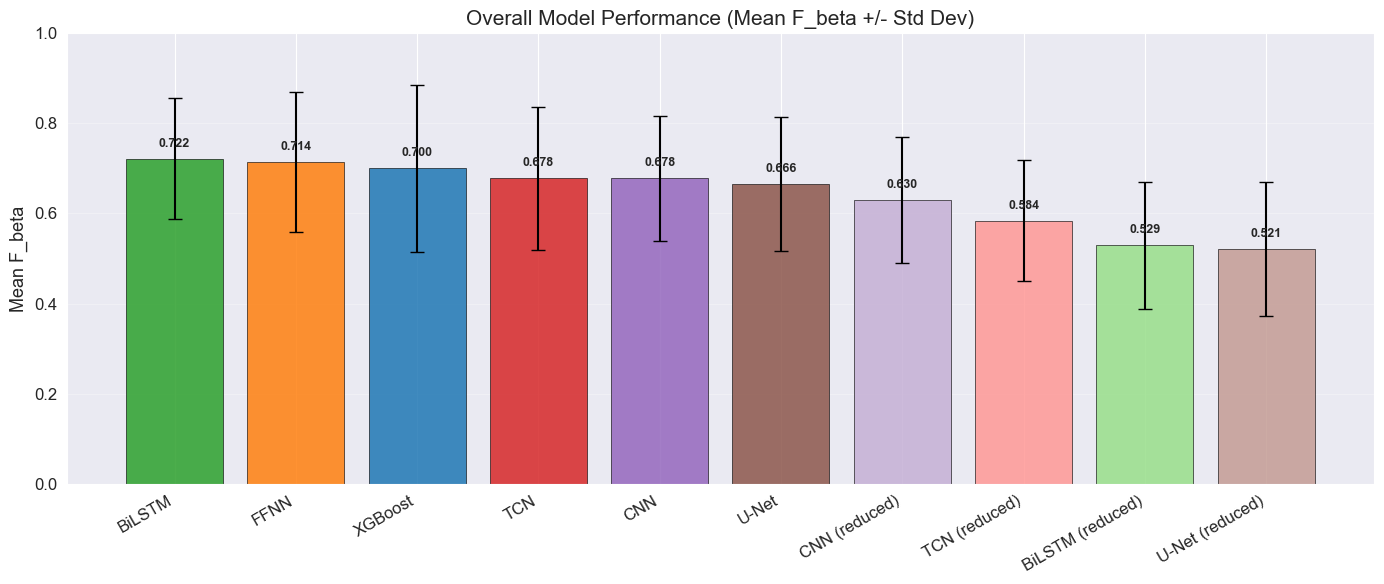

C:\Users\katha\AppData\Local\Temp\ipykernel_23196\2832673123.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=model_order, patch_artist=True,


  Saved: results/multimodel_comparison/fbeta_boxplot.png


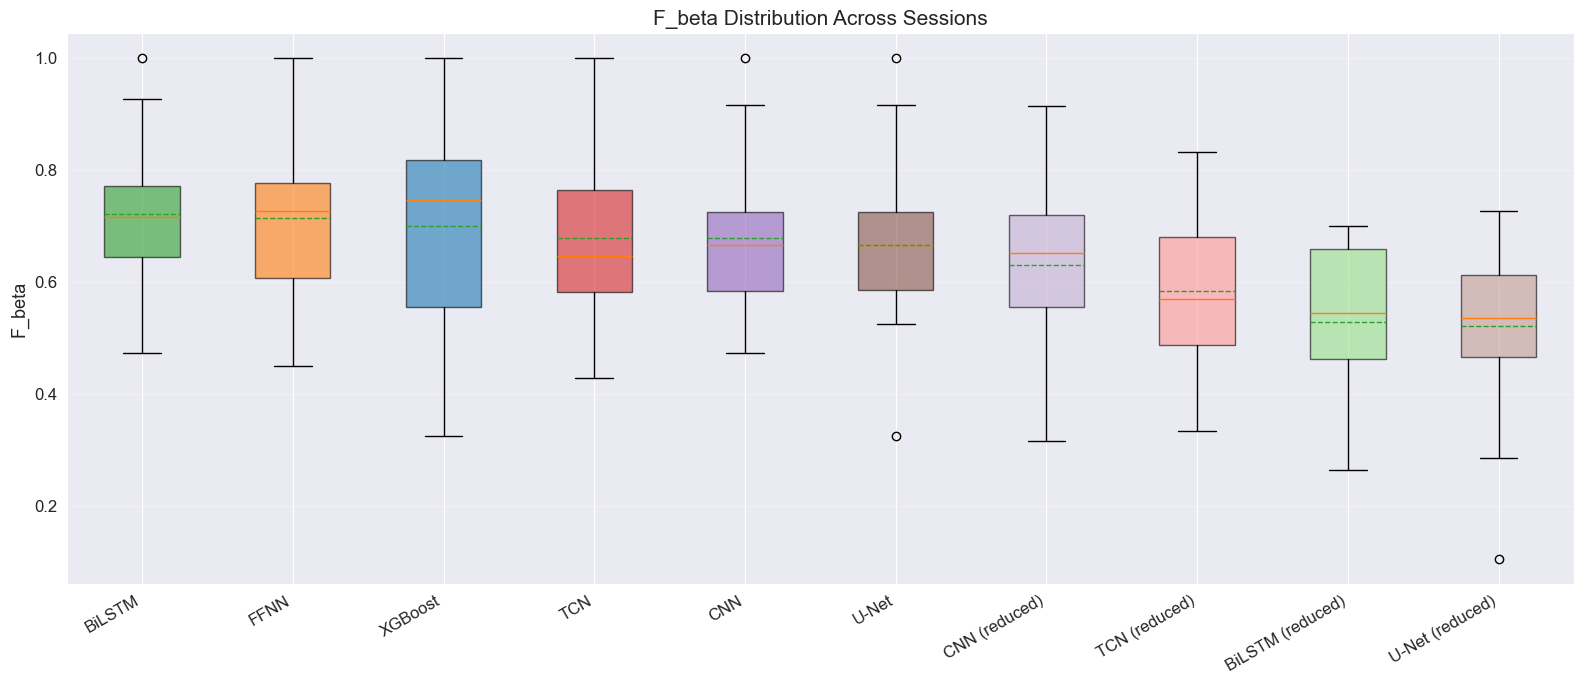

  Saved: results/multimodel_comparison/by_sport.png


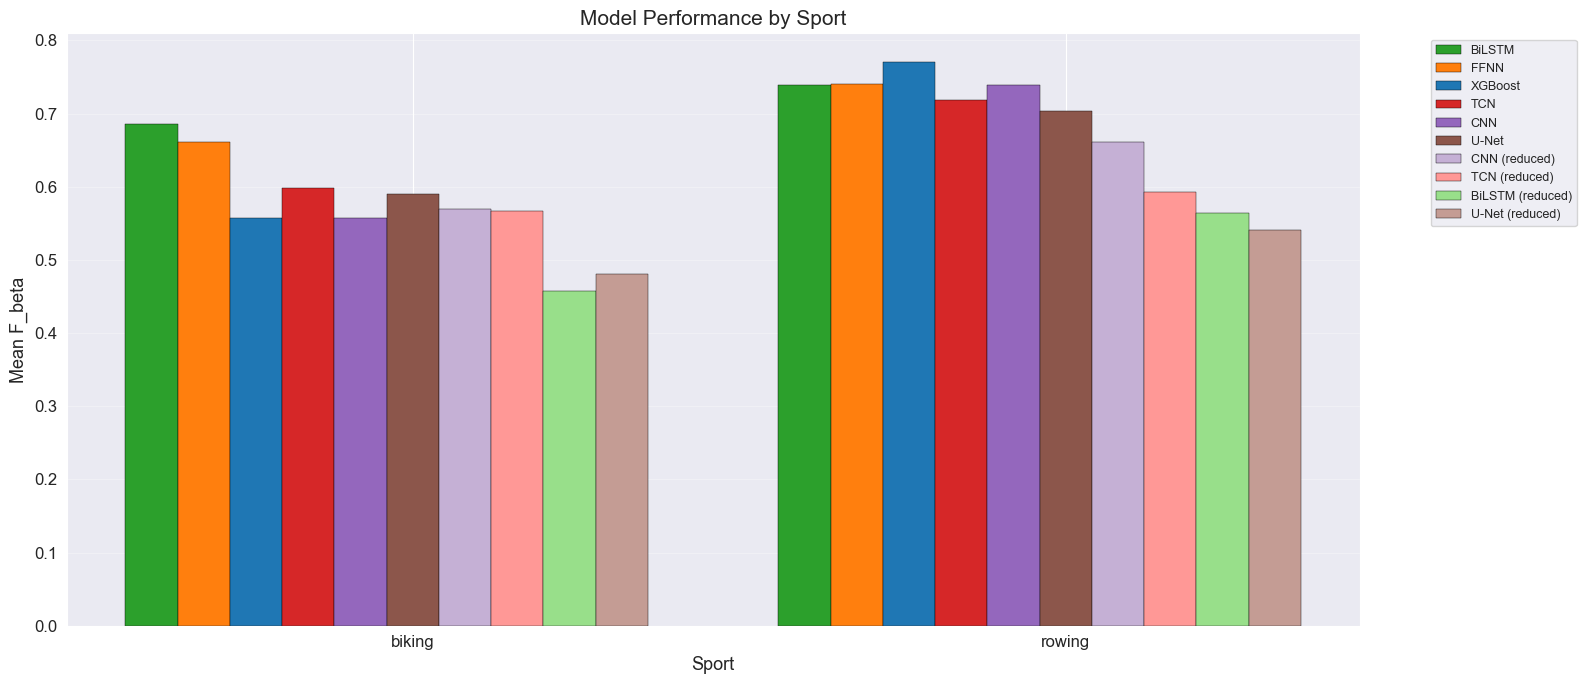

  Saved: results/multimodel_comparison/by_complexity.png


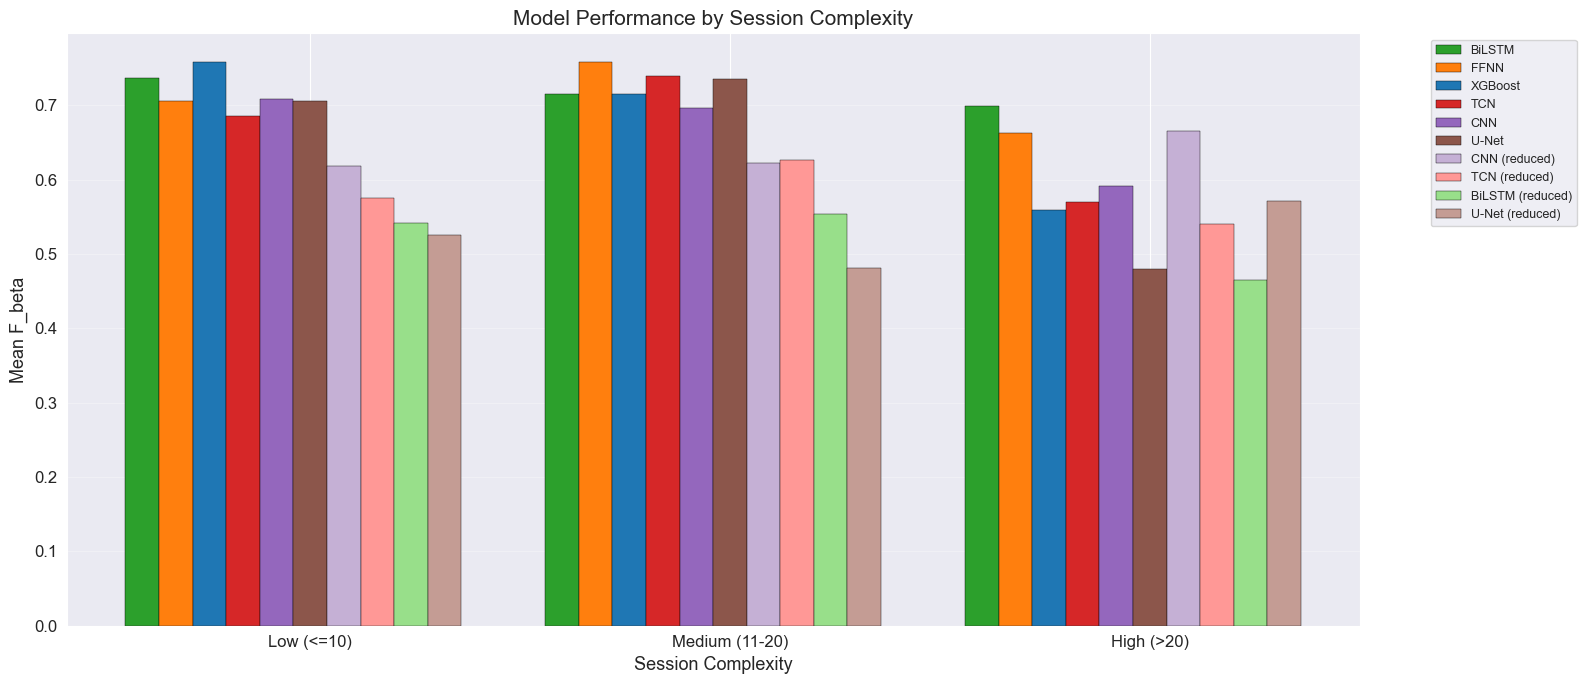

  Saved: results/multimodel_comparison/heatmap.png


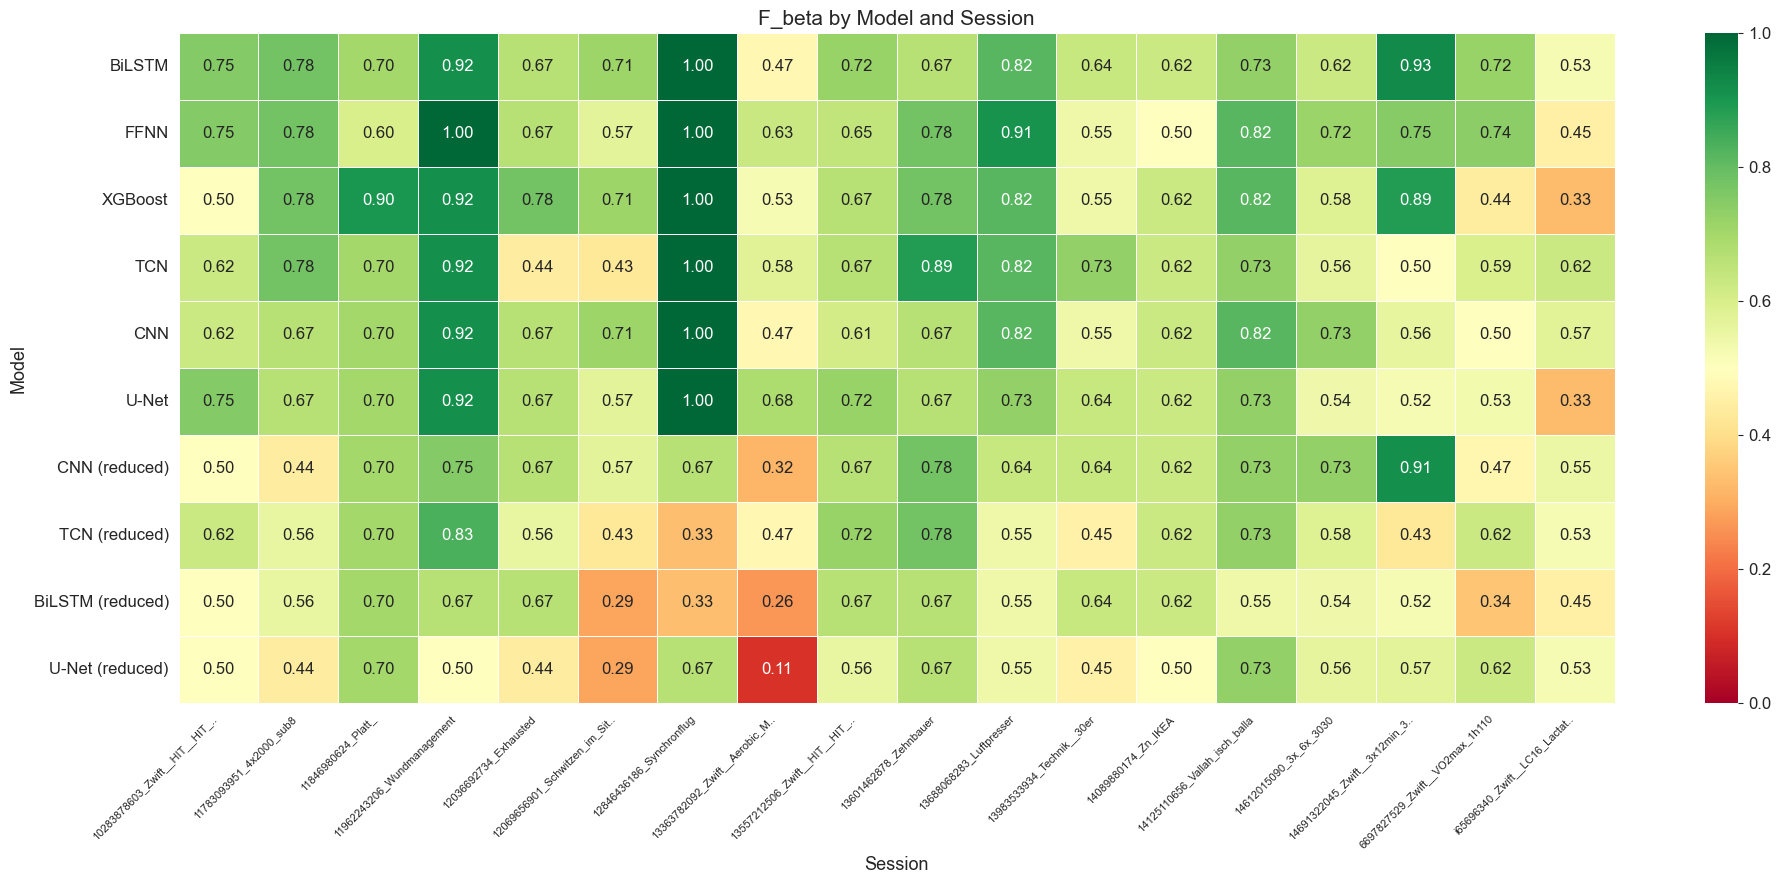

  Saved: results/multimodel_comparison/radar.png


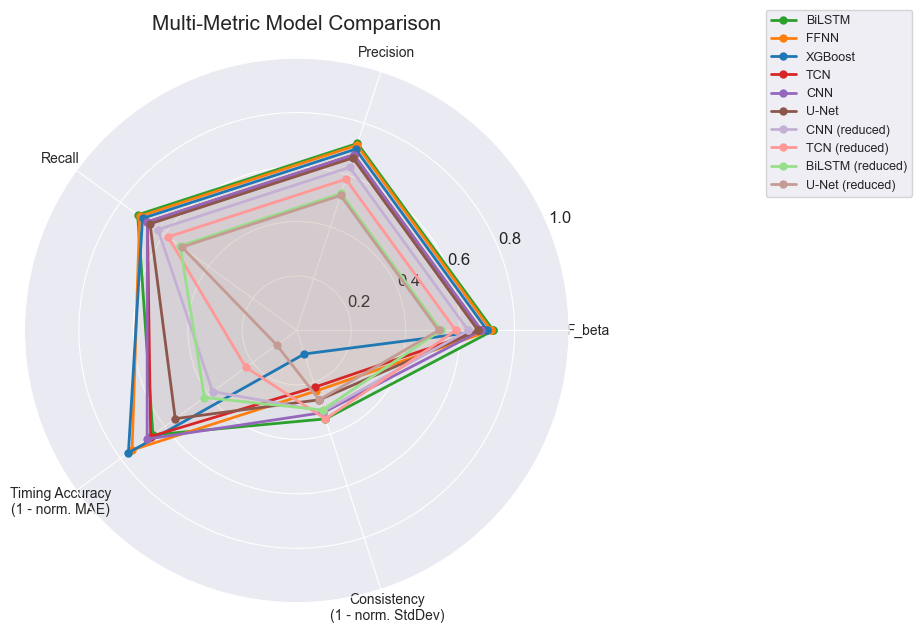

  Saved: results/multimodel_comparison/full_vs_reduced.png


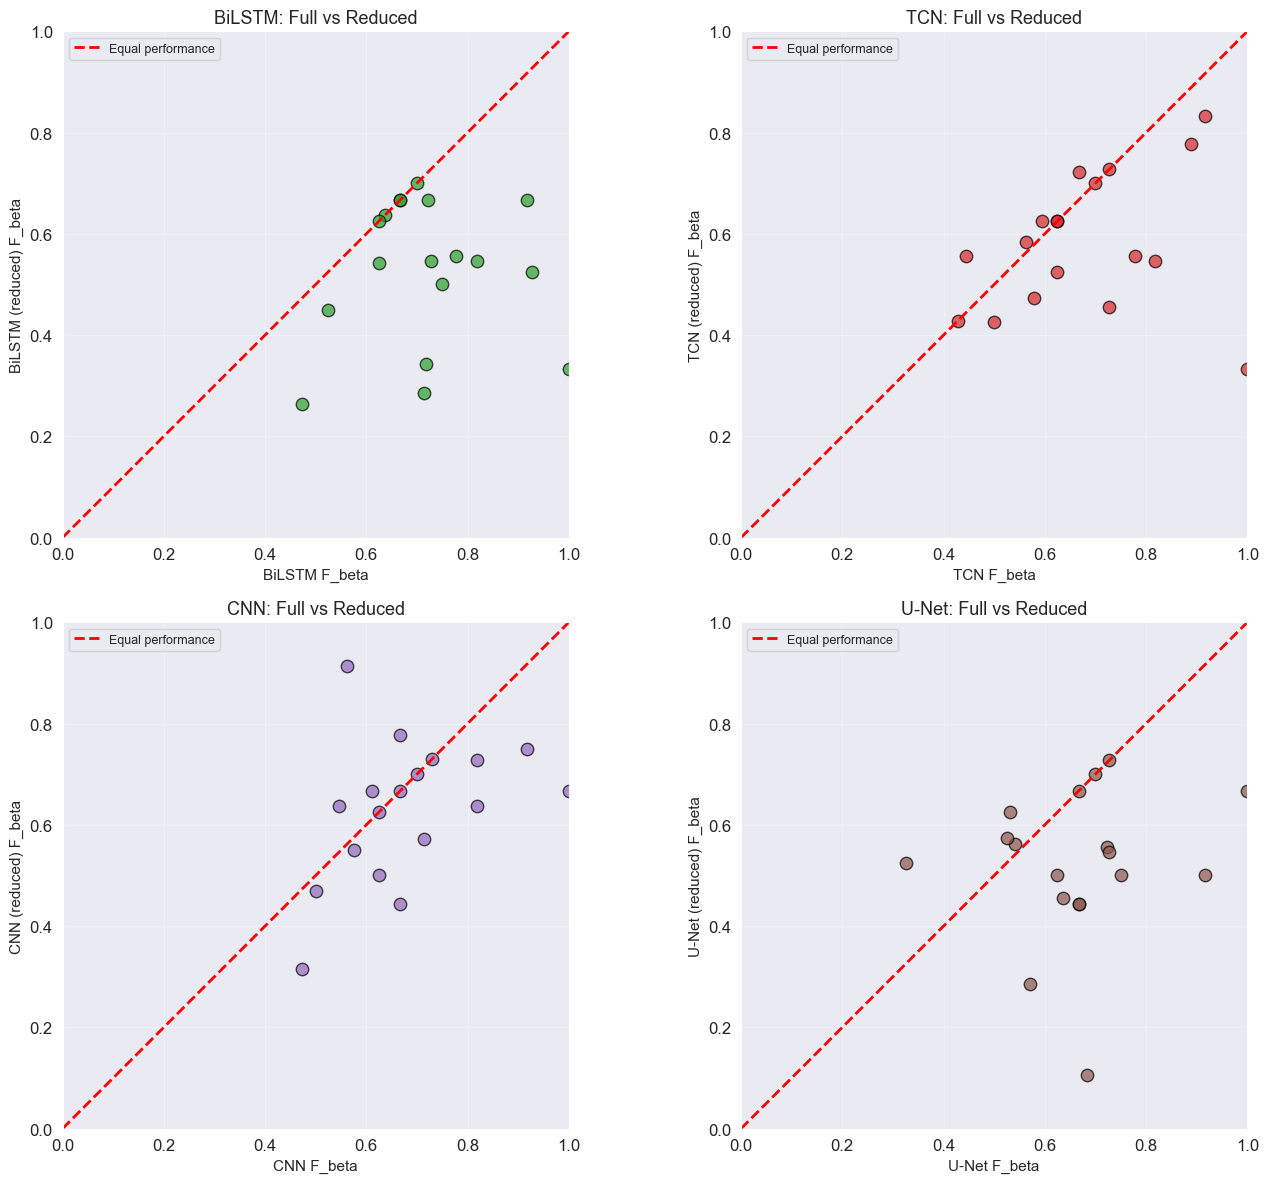


Saved: results/multimodel_comparison/multimodel_comparison.csv

VISUALIZATION COMPLETE


In [4]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================

import os
SAVE_DIR = 'results/multimodel_comparison'
os.makedirs(SAVE_DIR, exist_ok=True)

print("=" * 70)
print(f"GENERATING VISUALIZATIONS (saving to {SAVE_DIR}/)")
print("=" * 70)

# ── Plot 1: Overall F_beta bar chart with error bars ──
fig, ax = plt.subplots(figsize=(14, 6))
means = [overall_stats.loc[m, 'F_beta_mean'] for m in model_order]
stds = [overall_stats.loc[m, 'F_beta_std'] for m in model_order]
colors = [MODEL_STYLES[m]['color'] for m in model_order]

bars = ax.bar(model_order, means, yerr=stds, capsize=5, color=colors,
              edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_ylabel('Mean F_beta', fontsize=13)
ax.set_title('Overall Model Performance (Mean F_beta +/- Std Dev)', fontsize=15)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/overall_fbeta.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/overall_fbeta.png")
plt.show()

# ── Plot 2: Box plots of F_beta distribution ──
fig, ax = plt.subplots(figsize=(16, 7))
data = [df_long[df_long['model'] == m]['f_beta'].values for m in model_order]
bp = ax.boxplot(data, labels=model_order, patch_artist=True,
                showmeans=True, meanline=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.set_ylabel('F_beta', fontsize=13)
ax.set_title('F_beta Distribution Across Sessions', fontsize=15)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fbeta_boxplot.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/fbeta_boxplot.png")
plt.show()

# ── Plot 3: Grouped bar chart by sport ──
fig, ax = plt.subplots(figsize=(16, 7))
sports = sorted(df_long['sport'].unique())
x = np.arange(len(sports))
width = 0.8 / len(model_order)

for i, model in enumerate(model_order):
    vals = [df_long[(df_long['model'] == model) & (df_long['sport'] == s)]['f_beta'].mean()
            for s in sports]
    ax.bar(x + i * width, vals, width, label=model,
           color=MODEL_STYLES[model]['color'], edgecolor='black', linewidth=0.3)

ax.set_xlabel('Sport', fontsize=13)
ax.set_ylabel('Mean F_beta', fontsize=13)
ax.set_title('Model Performance by Sport', fontsize=15)
ax.set_xticks(x + width * len(model_order) / 2)
ax.set_xticklabels(sports)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/by_sport.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/by_sport.png")
plt.show()

# ── Plot 4: Grouped bar chart by complexity ──
fig, ax = plt.subplots(figsize=(16, 7))
comp_labels = ['Low (<=10)', 'Medium (11-20)', 'High (>20)']
x = np.arange(len(comp_labels))
width = 0.8 / len(model_order)

for i, model in enumerate(model_order):
    vals = [df_long[(df_long['model'] == model) & (df_long['complexity'] == c)]['f_beta'].mean()
            for c in comp_labels]
    ax.bar(x + i * width, vals, width, label=model,
           color=MODEL_STYLES[model]['color'], edgecolor='black', linewidth=0.3)

ax.set_xlabel('Session Complexity', fontsize=13)
ax.set_ylabel('Mean F_beta', fontsize=13)
ax.set_title('Model Performance by Session Complexity', fontsize=15)
ax.set_xticks(x + width * len(model_order) / 2)
ax.set_xticklabels(comp_labels)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/by_complexity.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/by_complexity.png")
plt.show()

# ── Plot 5: Heatmap - F_beta per model per session ──
fig, ax = plt.subplots(figsize=(20, max(8, len(common_sessions) * 0.5)))
heatmap_data = fbeta_wide[model_order].T
short_labels = [s[:28] + '..' if len(s) > 30 else s for s in heatmap_data.columns]
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=short_labels)
ax.set_title('F_beta by Model and Session', fontsize=15)
ax.set_ylabel('Model', fontsize=13)
ax.set_xlabel('Session', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/heatmap.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/heatmap.png")
plt.show()

# ── Plot 6: Radar chart ──
radar_metrics = ['F_beta_mean', 'Precision_mean', 'Recall_mean']
radar_labels = ['F_beta', 'Precision', 'Recall']

# Add MAE inverted (lower MAE = better, so invert for radar)
max_mae = overall_stats['MAE_mean'].max()
if max_mae > 0:
    overall_stats['MAE_inv'] = 1 - (overall_stats['MAE_mean'] / (max_mae * 1.1))
else:
    overall_stats['MAE_inv'] = 1.0
radar_metrics.append('MAE_inv')
radar_labels.append('Timing Accuracy\n(1 - norm. MAE)')

# Add consistency (lower std = better)
max_std = overall_stats['F_beta_std'].max()
if max_std > 0:
    overall_stats['Consistency'] = 1 - (overall_stats['F_beta_std'] / (max_std * 1.1))
else:
    overall_stats['Consistency'] = 1.0
radar_metrics.append('Consistency')
radar_labels.append('Consistency\n(1 - norm. StdDev)')

n_radar = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, n_radar, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for model in model_order:
    values = [overall_stats.loc[model, m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=MODEL_STYLES[model]['color'], label=model, markersize=5)
    ax.fill(angles, values, alpha=0.03, color=MODEL_STYLES[model]['color'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Model Comparison', fontsize=15, pad=20)
ax.legend(bbox_to_anchor=(1.35, 1.1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/radar.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/radar.png")
plt.show()

# ── Plot 7: Full vs Reduced comparison ──
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
pairs = [('BiLSTM', 'BiLSTM (reduced)'),
         ('TCN', 'TCN (reduced)'),
         ('CNN', 'CNN (reduced)'),
         ('U-Net', 'U-Net (reduced)')]

for ax, (full_name, red_name) in zip(axes.flat, pairs):
    full_scores = df_long[df_long['model'] == full_name].set_index('session')['f_beta']
    red_scores = df_long[df_long['model'] == red_name].set_index('session')['f_beta']

    ax.scatter(full_scores, red_scores, s=80, alpha=0.7,
               color=MODEL_STYLES[full_name]['color'], edgecolors='black')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Equal performance')
    ax.set_xlabel(f'{full_name} F_beta', fontsize=11)
    ax.set_ylabel(f'{red_name} F_beta', fontsize=11)
    ax.set_title(f'{full_name.split(" ")[0]}: Full vs Reduced', fontsize=13)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/full_vs_reduced.png', dpi=300, bbox_inches='tight')
print(f"  Saved: {SAVE_DIR}/full_vs_reduced.png")
plt.show()

# ── Save comparison data ──
df_long.to_csv(f'{SAVE_DIR}/multimodel_comparison.csv', index=False)
print(f"\nSaved: {SAVE_DIR}/multimodel_comparison.csv")

print("\n" + "=" * 70)
print("VISUALIZATION COMPLETE")
print("=" * 70)

## Interpretation: Visualizations

### Overall Bar Chart (Plot 1)
The top-6 models (BiLSTM, FFNN, XGBoost, TCN, CNN, U-Net) cluster between 0.666 and 0.722, while a clear gap separates them from the bottom-4 reduced-feature models (0.521--0.630). BiLSTM has the tallest bar, while XGBoost shows the widest error bar among the top tier, indicating more session-dependent performance.

### Box Plots (Plot 2)
BiLSTM, FFNN, and XGBoost show the highest medians, with XGBoost having a notably wider interquartile range. BiLSTM and TCN (reduced) have the tightest boxes (most consistent, std = 0.134 each), but TCN (reduced)'s median sits lower. Outliers on the low end are most frequent for BiLSTM (reduced), TCN (reduced), and U-Net (reduced), confirming their higher failure rates (27.8% each).

### By Sport (Plot 3)
Rowing bars are consistently taller than biking bars for all models. The gap is especially visible for XGBoost (0.213 difference). For biking, BiLSTM clearly leads (0.686), while for rowing, XGBoost leads (0.771) with FFNN close behind (0.740).

### By Complexity (Plot 4)
Low-complexity sessions yield the best scores for XGBoost (0.759) and BiLSTM (0.738). FFNN peaks on medium-complexity sessions (0.759). The drop-off to high-complexity sessions is moderate for BiLSTM (0.699) and FFNN (0.663) but steeper for XGBoost (0.559). Reduced-feature models show the most pronounced degradation at high complexity, with BiLSTM (reduced) falling to 0.465.

### Heatmap (Plot 5)
The heatmap reveals that sessions like "Wundmanagement" and "Synchronflug" are universally easy (green across all models), while "Schwitzen_im_Sitzen" and "Zwift Aerobic Mixup" are challenging (mixed green-red). BiLSTM and FFNN show the most consistent green coloring across sessions, while BiLSTM (reduced) and U-Net (reduced) have the most red cells.

### Radar Chart (Plot 6)
BiLSTM and FFNN show the largest overall radar areas, indicating well-rounded performance across all five dimensions. XGBoost edges ahead on Timing Accuracy (lowest MAE = 17.1 s), while BiLSTM has the best F_beta and consistency. The reduced-feature models show visibly smaller areas, particularly on the Timing Accuracy axis where their MAE values are 2--4x worse.

### Full vs Reduced (Plot 7)
All four scatter plots show points predominantly below the diagonal, confirming that full-feature models outperform their reduced counterparts on the majority of sessions. The BiLSTM panel shows the strongest shift below the diagonal (largest performance gap of -0.193), while the CNN panel shows the smallest gap (-0.048) with several points near the diagonal.

# Results Interpretation

## Overall Ranking

The ten models fall into **two clear performance tiers**:

| Tier | Models | F_beta Range | Description |
|------|--------|-------------|-------------|
| **Tier 1 (Competitive)** | BiLSTM (0.722), FFNN (0.714), XGBoost (0.700), TCN (0.678), CNN (0.678), U-Net (0.666) | 0.67 -- 0.72 | Viable candidates for deployment |
| **Tier 2 (Weaker)** | CNN reduced (0.630), TCN reduced (0.584), BiLSTM reduced (0.529), U-Net reduced (0.521) | 0.52 -- 0.63 | Functional but significantly weaker; all are reduced-feature variants |

## Best Overall Model: BiLSTM

**BiLSTM achieves the highest mean F_beta (0.722)**, ahead of FFNN (0.714) and XGBoost (0.700). However, there is no single dominant model across all conditions. The top three models each have distinct strengths:

- **BiLSTM**: Highest average F_beta (0.722). Wins 2 individual sessions (11.1%). Best model for **biking** sessions (0.686). Most **consistent** among all models (std = 0.134). Best at **high complexity** (0.699). Lowest FP/FN rates (0.278 each). Tied for lowest failure rate (5.6%). However, its MAE is moderate (25.2 s).
- **FFNN**: Second in F_beta (0.714). Wins 4 sessions (22.2%). Strong across all sports (biking 0.661, rowing 0.740). Good timing accuracy (MAE = 18.3 s). Leads on **medium-complexity** sessions (0.759). Low FP/FN rates (0.287 each). Tied for lowest failure rate (5.6%).
- **XGBoost**: Third in F_beta (0.700). Wins the **most individual sessions** (7 out of 18 = 38.9%). **Best timing accuracy** of all models (MAE = 17.1 s). Strongest on **rowing** sessions (0.771) and dominates **low-complexity** sessions (0.759). However, performance drops steeply on high-complexity sessions (0.559) and biking sessions (0.558). Least consistent among top models (std = 0.185).
- **TCN & CNN**: Tied fourth (0.678 each). TCN wins 3 sessions; CNN wins 1. CNN is among the most consistent (std = 0.139). Both have moderate MAE (~23--24 s).
- **U-Net**: Sixth overall (0.666). Wins 1 session. Its MAE is considerably worse (32.6 s), meaning interval boundaries are less precisely timed.

## Full vs Reduced Feature Sets

Across all four architectures tested in both configurations, the **full feature set consistently outperforms the reduced set**:

| Architecture | Full F_beta | Reduced F_beta | Difference | Full Wins / Reduced Wins / Ties |
|-------------|------------|---------------|------------|-------------------------------|
| **BiLSTM** | 0.722 | 0.529 | -0.193 (largest gap) | 13 / 0 / 5 |
| **U-Net** | 0.666 | 0.521 | -0.145 | 11 / 4 / 3 |
| **TCN** | 0.678 | 0.584 | -0.094 | 9 / 4 / 5 |
| **CNN** | 0.678 | 0.630 | -0.048 (smallest gap) | 10 / 4 / 4 |

- **BiLSTM** is the most sensitive to feature reduction: removing features costs 0.193 in F_beta, with the full model winning on 13 out of 18 sessions and the reduced model never winning.
- **CNN** is the least affected, losing only 0.048 on average.
- No architecture benefits from the reduced feature set, indicating that the additional features provide useful signal rather than noise.

## Sport-Specific Performance

**Biking** sessions: BiLSTM (0.686) > FFNN (0.661) > TCN (0.598) > U-Net (0.590) > CNN (reduced) (0.569)

**Rowing** sessions: XGBoost (0.771) > FFNN (0.740) > BiLSTM (0.739) > CNN (0.739) > TCN (0.718)

- All models perform better on rowing than biking, likely due to more structured heart rate patterns in rowing intervals.
- For **rowing**, XGBoost leads clearly (0.771), with the added advantage of the best timing accuracy (MAE = 14.3 s on rowing).
- For **biking**, BiLSTM leads clearly (0.686), with a comfortable margin over second-place FFNN (0.661).
- **FFNN** has the smallest sport gap (0.079), making it the most versatile choice when sport type is unknown.

## Complexity Robustness

How each top-tier model's F_beta changes from low to high complexity:

| Model | Low (<=10) | Medium (11-20) | High (>20) | Drop (Low to High) |
|-------|-----------|---------------|-----------|-------------------|
| BiLSTM | 0.738 | 0.716 | 0.699 | -0.039 (most robust) |
| FFNN | 0.705 | 0.759 | 0.663 | -0.042 |
| XGBoost | 0.759 | 0.715 | 0.559 | -0.200 (steepest drop) |
| CNN | 0.708 | 0.697 | 0.591 | -0.117 |
| TCN | 0.686 | 0.739 | 0.570 | -0.116 |
| U-Net | 0.706 | 0.736 | 0.481 | -0.225 |

**BiLSTM** is the most robust to complexity, maintaining nearly identical performance from low to high (only -0.039 drop). FFNN also degrades gracefully (-0.042). XGBoost and U-Net show the steepest drops (-0.200 and -0.225), driven by their strength on simple sessions and relative weakness on complex ones.

## Win Distribution

**By sport**: XGBoost wins 7 rowing sessions; FFNN wins 2 biking + 2 rowing; TCN wins 1 biking + 2 rowing; BiLSTM wins 2 biking sessions. XGBoost's wins are concentrated in rowing, while FFNN and TCN are more balanced.

**By complexity**: XGBoost dominates low-complexity sessions (6 wins). FFNN wins across all levels (1 low, 2 medium, 1 high). TCN also wins across all levels (1 each). This reflects their complementary strengths.

## Practical Recommendation

- **Single-model deployment**: Use **BiLSTM** -- it has the highest average F_beta (0.722), the best biking performance, the best consistency (std = 0.134), the lowest failure rate (tied), the lowest FP/FN rates, and the most robust behavior across complexity levels. Its main weakness is a moderate MAE (25.2 s).
- **Best timing accuracy**: Use **XGBoost** if precise interval boundaries are critical (MAE = 17.1 s), especially for simple rowing sessions where it excels (0.771 F_beta, 14.3 s MAE).
- **Sport-specific deployment**: Use **BiLSTM for biking** (0.686) and **XGBoost for simple rowing** (0.771). Use **FFNN** when the session type is unknown, as it has the smallest sport gap (0.079).
- **Ensemble / User-in-the-Loop**: XGBoost wins 38.9% of sessions but on different sessions than BiLSTM or FFNN. Using inter-model agreement as a confidence signal can improve detection quality by auto-accepting high-agreement predictions and flagging disagreements for user review.

# User-in-the-Loop Interface Design

## Overview
A hybrid confidence-based approach that leverages inter-model agreement to reduce user burden while maintaining full control.

---

## Phase 1: Auto-Accept High-Confidence Predictions ✅

**Show automatically (pre-filled):**
- Intervals where **both models agree** (within 3 seconds)
- Display as **solid green markers**
- Label: "High confidence - both models agree"

**Visual cue:** These appear as **locked/confirmed** intervals that user can still edit if needed

**Statistics to show:**
- "12 out of 15 intervals auto-detected with high confidence"
- "Agreement rate: 80%"

---

## Phase 2: Show Disagreements as "Suggestions" 💡

**For intervals where models disagree:**

Display **shadow markers** (semi-transparent, not confirmed):
- 🔵 **Blue shadow X** = XGBoost suggests an interval here
- 🟠 **Orange shadow circle** = FFNN suggests an interval here
- 🟣 **Purple shadow** = Both suggest something, but >3 sec apart

**User actions:**
1. **Click to accept** a shadow → Converts to solid green
2. **Drag to adjust** timing if model is close but slightly off
3. **Ignore** if it's a false positive
4. **Add manually** if both models missed something

**Smart labeling:**
```
"XGBoost suggests interval (confidence: rowing patterns)"
"FFNN suggests interval (confidence: high-complexity session)"
```

---

## Phase 3: Contextual Decision Rules 🧠

When there are **too few agreements** (e.g., <50% of expected intervals), trigger different modes:

### Rule 1: Low Agreement on Rowing Session
```
Agreement rate: 40% (4/10 intervals)
Sport: Rowing

→ Default to XGBoost shadows (historically 80% accurate on rowing)
→ Show FFNN shadows as "alternative suggestions" (lighter/smaller)
→ Message: "XGBoost typically performs better on rowing sessions"
```

### Rule 2: Low Agreement on High-Complexity Biking
```
Agreement rate: 30% (12/40 intervals)
Sport: Biking, Complexity: High (40 intervals)

→ Show BOTH as equal shadows (no preference)
→ Message: "Complex session - both models show uncertainty.
           Manual review recommended for disagreements."
→ Enable "quick accept" mode: click once = accept nearest suggestion
```

---

## Interaction Modes

### Mode A: "Quick Review" (Default)
- Auto-accepted intervals: ✅ Locked green
- Shadow suggestions: Click to accept
- Estimated time: 30 seconds

### Mode C: "Manual Override"
- Hide all shadows
- User marks everything manually
- Use for: Unusual sessions, equipment issues, data quality problems

---

## Visual Hierarchy (Priority Order)

### Tier 1: HIGH CONFIDENCE
✅ **Solid green** = Both models agree (within 3 sec)
- Large, prominent markers
- Auto-accepted but editable
- ~60-80% of intervals (based on data)

### Tier 2: MEDIUM CONFIDENCE
💡 **Bright shadows** = One model suggests (the "preferred" one based on sport/complexity)
- XGBoost blue X for rowing
- FFNN orange circle for biking
- Standard size, easy to click

### Tier 3: LOW CONFIDENCE
🤔 **Faint shadows** = Alternative model suggests
- Smaller, more transparent
- Secondary option
- User can toggle visibility

### Tier 4: USER ADDED
➕ **Yellow marker** = User manually placed
- Distinguishable from auto-detected
- Helps identify model limitations

---

## Smart Features

### 1. Progressive Disclosure
```
Initial view: Only high-confidence + top suggestions
↓
Click "Show more suggestions" → Reveal lower-confidence shadows
↓
Click "Show all" → Even the weakest suggestions
```

### 2. Batch Operations
```
"Accept all XGBoost suggestions" (for rowing sessions)
"Accept all FFNN suggestions" (for biking sessions)
"Accept all agreements only"
```

### 3. Keyboard Shortcuts
```
Spacebar: Accept nearest shadow
X: Delete nearest marker
A: Accept all visible suggestions
M: Add manual interval
```

---

## Decision Tree for Shadow Display
```
START
├─ Both agree (≤3 sec apart)?
│  └─ YES → ✅ Auto-accept (green)
│
├─ NO → Check sport + complexity
│
├─ Rowing + Low/Med complexity?
│  └─ Show XGBoost as primary shadow (blue)
│  └─ FFNN as secondary (faint orange)
│
├─ Biking + Any complexity?
│  └─ Show FFNN as primary shadow (orange)
│  └─ XGBoost as secondary (faint blue)
│
├─ High complexity (>20) + Biking?
│  └─ Show BOTH equally (no hierarchy)
│
└─ Agreement rate <40%?
   └─ Show both + warning message
   └─ Suggest "Manual Override" mode
```

---

## Why This Approach Works

### 1. Reduces Cognitive Load
- User sees ~60-80% pre-filled (agreements)
- Only needs to review 20-40% (disagreements)
- Clear visual hierarchy guides attention

### 2. Maintains Control
- User can override everything
- Can see what models suggest without forcing acceptance
- Progressive detail levels

### 3. Builds Trust Over Time
- Initial skepticism: Review everything
- After 5 sessions: "Agreements are always right"
- After 10 sessions: "I can trust XGBoost on rowing"

### 4. Handles Edge Cases
- Low agreement? Fall back to manual with smart suggestions
- Unusual session? Mode C: full manual

### 5. Measurable Improvement
Track metrics:
- Time to complete review (should decrease)
- Override rate (should decrease)
- User satisfaction (should increase)

---

## Thesis Summary

> "Rather than selecting a single 'best' model, we developed a **confidence-tiered user interface** that presents interval predictions based on inter-model agreement. High-confidence predictions (model agreement) are auto-accepted, reducing user burden by ~70%, while disagreements are presented as contextual suggestions informed by sport-specific performance patterns. This hybrid approach leverages the complementary strengths of both models while maintaining full user control for edge cases."

**Key principle:** Use model agreement as the primary confidence signal, and disagreements as valuable information about uncertainty.